<a href="https://colab.research.google.com/github/papoochu/EE-467-Machine-Learning-for-Cybersecurity/blob/main/Assignment_3_Student.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# EE P595 Homework 3: Identifying Malicious URLs (PyTorch)

<span style="color:red">**Released Date: February 5, 2026**</span>  
<span style="color:red">**Due Date: February 22, 2026**</span>

Build a 1D CNN to classify malicious HTTP request URLs using N-gram embeddings.

**Key Concepts:** N-gram extraction, Co-occurrence matrix, TruncatedSVD, 1D CNN

**Teammate:** _(Name if applicable)_

In [1]:
%pip install torch tqdm assertpy scikit-learn pandas matplotlib

  Preparing metadata (setup.py) ... done
  Created wheel for assertpy: filename=assertpy-1.1-py3-none-any.whl size=42897 sha256=c1f3646ae445f1432c91434e8725bb50d683987706ebc7b7b2b55d05f104aba9
  Stored in directory: /root/.cache/pip/wheels/e9/a6/9e/a5cead15269b79ab7ebf051cfc3f7adcbd5a880e683e94736a
Successfully built assertpy


In [4]:
!tar -xJf waf-urls.tar.xz

## 1. Data Loading

In [5]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

# Load WAF URLs dataset
df = pd.read_csv('./waf-urls.csv')
print(f'Dataset: {len(df)} URLs')

# Split: 60% train, 20% val, 20% test
urls_tv, urls_test, labels_tv, labels_test = train_test_split(
    df['url'], df['label'], test_size=0.2, random_state=12345)
urls_train, urls_vali, labels_train, labels_vali = train_test_split(
    urls_tv, labels_tv, test_size=0.25, random_state=12345)

print(f'Train: {len(urls_train)}, Val: {len(urls_vali)}, Test: {len(urls_test)}')

Dataset: 60547 URLs
Train: 36327, Val: 12110, Test: 12110


## 2. N-Gram Functions

In [15]:
from assertpy import assert_that
from tqdm import tqdm

def iter_ngrams(text, n, start_symbol='\x00', end_symbol='\x01'):
    """Generate N-grams with start/end padding."""
    ## [ TODO 1 ] Implement N-gram generation
    # - Pad (n-1) start_symbols before text
    # - Pad n end_symbols after text
    # - Return generator of N-grams
    padded = start_symbol * (n - 1) + text + end_symbol * n

    for i in range(len(padded) - n + 1):
        yield padded[i:i+n]

# Test
assert_that(list(iter_ngrams('/test', n=3))).is_equal_to([
    '\x00\x00/', '\x00/t', '/te', 'tes', 'est', 'st\x01', 't\x01\x01', '\x01\x01\x01'
])

In [16]:
def build_ngram_mapping(urls, n, rare_threshold=2):
    """Build bidirectional N-gram to index mapping."""
    ngram_count = {}

    print('Counting N-grams...')
    for url in tqdm(urls):
        for ngram in iter_ngrams(url, n):
            ## [ TODO 2.1 ] Count N-gram occurrences
            ngram_count[ngram] = ngram_count.get(ngram, 0) + 1

    n2i, i2n = {}, []
    n_rare = 0

    print('Building mapping...')
    for ngram, count in tqdm(ngram_count.items()):
        ## [ TODO 2.2 ] Build mapping (only if count >= rare_threshold)
        # - Add to n2i and i2n if frequent
        # - Track n_rare for rare N-grams
        if count >= rare_threshold:
            n2i[ngram] = len(i2n)
            i2n.append(ngram)
        else:
            n_rare += 1

    print(f'Unique: {len(ngram_count)}, Kept: {len(i2n)}')
    return n2i, i2n

# Test
n2i_test, i2n_test = build_ngram_mapping(['/x', '/xyz/23', '/233'], n=3)
assert_that(len(n2i_test)).is_equal_to(5)

Counting N-grams...


100%|██████████| 3/3 [00:00<00:00, 25015.73it/s]


Building mapping...


100%|██████████| 15/15 [00:00<00:00, 104857.60it/s]

Unique: 15, Kept: 5


## 3. Co-occurrence Matrix

In [18]:
from scipy.sparse import dok_matrix

def build_cooccurrence_matrix(urls, n, n2i_mapping, window_size):
    """Build normalized co-occurrence matrix."""
    n_ngram = len(n2i_mapping)
    unknown_idx = n_ngram
    co_matrix = dok_matrix((n_ngram+1, n_ngram+1))

    print(f'Building co-occurrence...')
    for url in tqdm(urls):
        prev_indices = []
        for ngram in iter_ngrams(url, n):
            ## [ TODO 3.1 ] Get N-gram index (unknown_idx if not found)
            idx = n2i_mapping.get(ngram, unknown_idx)

            ## [ TODO 3.2 ] Update co-occurrence for prev neighbors in window
            for p in prev_indices:
                co_matrix[p, idx] = co_matrix.get((p, idx), 0) + 1
                co_matrix[idx, p] = co_matrix.get((idx, p), 0) + 1

            prev_indices.append(idx)
            if len(prev_indices) > window_size:
                prev_indices.pop(0)

    print('Normalizing...')
    row_sums = co_matrix.sum(axis=1)
    ## [ TODO 3.3 ] Normalize rows to probability distributions
    for (i, j) in tqdm(list(co_matrix.keys())):
        total = row_sums[i, 0]
        if total > 0:y
            co_matrix[i, j] /= total

    return co_matrix

In [19]:
# Build N-gram mapping and co-occurrence matrix
N = 4
WINDOW_SIZE = 5

n2i_urls, i2n_urls = build_ngram_mapping(urls_train, N)
cooccurrence_urls = build_cooccurrence_matrix(urls_train, N, n2i_urls, WINDOW_SIZE)
print(f'Co-occurrence shape: {cooccurrence_urls.shape}')

Counting N-grams...


100%|██████████| 36327/36327 [00:00<00:00, 42528.42it/s]


Building mapping...


100%|██████████| 160195/160195 [00:00<00:00, 2228272.25it/s]


Unique: 160195, Kept: 82844
Building co-occurrence...


100%|██████████| 36327/36327 [05:08<00:00, 117.91it/s]


Normalizing...


100%|██████████| 2542234/2542234 [00:58<00:00, 43134.66it/s]

Co-occurrence shape: (82845, 82845)


## 4. Embedding via TruncatedSVD

In [20]:
from sklearn.decomposition import TruncatedSVD

EMBEDDING_DIMS = 10

## [ TODO 4 ] Create TruncatedSVD and fit_transform co-occurrence matrix
# svd = TruncatedSVD(n_components=EMBEDDING_DIMS, n_iter=20, random_state=42)
# embedding_svd = svd.fit_transform(cooccurrence_urls)
svd = TruncatedSVD(n_components=EMBEDDING_DIMS, n_iter=20, random_state=42)
embedding_svd = svd.fit_transform(cooccurrence_urls)

assert embedding_svd.shape == (len(n2i_urls)+1, EMBEDDING_DIMS)

## 5. PyTorch Model

In [21]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

Device: cpu


In [22]:
def transform_urls(urls, padded_len, n, n2i_mapping, pad_symbol='\x01'):
    """Convert URLs to N-gram index sequences."""
    batch = np.empty((len(urls), padded_len + n), dtype=int)
    unknown_idx = len(n2i_mapping)

    for i, url in enumerate(urls):
        ## [ TODO 5.1 ] Pad URL to padded_len
        url = url.ljust(padded_len, pad_symbol)

        ## [ TODO 5.2 ] Convert N-grams to indices
        for j, ngram in enumerate(iter_ngrams(url, n)):
            batch[i, j] = n2i_mapping.get(ngram, unknown_idx)

    return batch

In [23]:
class URLDataset(Dataset):
    def __init__(self, urls, labels, padded_len, n, n2i_mapping):
        self.data = transform_urls(list(urls), padded_len, n, n2i_mapping)
        self.labels = labels.values.astype(np.float32)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return torch.tensor(self.data[idx], dtype=torch.long), torch.tensor(self.labels[idx])

In [24]:
class URLCNN(nn.Module):
    """1D CNN for URL classification."""
    def __init__(self, n_ngram, embedding_weights, dropout=0.25):
        super().__init__()
        embed_dim = embedding_weights.shape[1]

        ## [ TODO 6.1 ] Embedding layer (frozen, initialized with embedding_weights)
        self.embedding = nn.Embedding(n_ngram + 1, embed_dim)
        self.embedding.weight = nn.Parameter(
            torch.tensor(embedding_weights, dtype=torch.float32),
            requires_grad=False
        )

        ## [ TODO 6.2 ] Conv blocks
        # conv1: embed_dim -> 20, kernel=5, padding=2
        # conv2: 20 -> 40, kernel=5, padding=2
        # conv3: 40 -> 80, kernel=5, padding=2
        # pool1: MaxPool1d(2), pool2: MaxPool1d(5), pool3: MaxPool1d(5)
        self.conv1 = nn.Conv1d(embed_dim, 20, kernel_size=5, padding=2)
        self.pool1 = nn.MaxPool1d(2)

        self.conv2 = nn.Conv1d(20, 40, kernel_size=5, padding=2)
        self.pool2 = nn.MaxPool1d(5)

        self.conv3 = nn.Conv1d(40, 80, kernel_size=5, padding=2)
        self.pool3 = nn.MaxPool1d(5)

        self.dropout = nn.Dropout(dropout)

        ## [ TODO 6.3 ] FC layers
        # fc1: 160 -> 16, fc2: 16 -> 1
        self.fc1 = nn.Linear(160, 16)
        self.fc2 = nn.Linear(16, 1)

    def forward(self, x):
        ## [ TODO 6.4 ] Forward pass
        # Embedding -> permute -> conv blocks -> flatten -> FC -> sigmoid
        x = self.embedding(x)
        x = x.permute(0, 2, 1)

        x = self.pool1(torch.relu(self.conv1(x)))
        x = self.pool2(torch.relu(self.conv2(x)))
        x = self.pool3(torch.relu(self.conv3(x)))

        x = x.flatten(1)
        x = self.dropout(torch.relu(self.fc1(x)))
        x = torch.sigmoid(self.fc2(x))

        return x

In [25]:
# Hyperparameters
BATCH_SIZE = 256
MAX_URL_LEN = 96
N_EPOCHS = 10

# Create datasets
train_dataset = URLDataset(urls_train, labels_train, MAX_URL_LEN, N, n2i_urls)
val_dataset = URLDataset(urls_vali, labels_vali, MAX_URL_LEN, N, n2i_urls)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE)

model = URLCNN(len(n2i_urls), embedding_svd).to(device)
criterion = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters())

In [30]:
def train_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        y = y.unsqueeze(1)
        ## [ TODO 7 ] Training step
        # optimizer.zero_grad(), forward, loss, backward, step
        optimizer.zero_grad()
        out = model(x)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * len(y)
        correct += ((out > 0.5) == y).sum().item()
        total += len(y)
    return total_loss / total, correct / total

def evaluate(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            y = y.unsqueeze(1)
            out = model(x)
            total_loss += criterion(out, y).item() * len(y)
            correct += ((out > 0.5) == y).sum().item()
            total += len(y)
    return total_loss / total, correct / total

In [40]:
# Training loop
history = {'loss': [], 'acc': [], 'val_loss': [], 'val_acc': []}

for epoch in range(N_EPOCHS):
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer)
    val_loss, val_acc = evaluate(model, val_loader, criterion)
    history['loss'].append(train_loss)
    history['acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    print(f'Epoch {epoch+1}: Train Acc={train_acc:.4f}, Val Acc={val_acc:.4f},  Train Loss={train_loss:.4f}, Val Loss={val_loss:.4f}')

torch.save(model.state_dict(), './model-url-cnn.pt')

Epoch 1: Train Acc=0.9724, Val Acc=0.9661,  Train Loss=0.0692, Val Loss=0.0799
Epoch 2: Train Acc=0.9708, Val Acc=0.9640,  Train Loss=0.0698, Val Loss=0.0819
Epoch 3: Train Acc=0.9738, Val Acc=0.9706,  Train Loss=0.0651, Val Loss=0.0723
Epoch 4: Train Acc=0.9739, Val Acc=0.9711,  Train Loss=0.0644, Val Loss=0.0716
Epoch 5: Train Acc=0.9733, Val Acc=0.9705,  Train Loss=0.0655, Val Loss=0.0726
Epoch 6: Train Acc=0.9742, Val Acc=0.9723,  Train Loss=0.0638, Val Loss=0.0713
Epoch 7: Train Acc=0.9726, Val Acc=0.9713,  Train Loss=0.0652, Val Loss=0.0693
Epoch 8: Train Acc=0.9765, Val Acc=0.9709,  Train Loss=0.0608, Val Loss=0.0701
Epoch 9: Train Acc=0.9770, Val Acc=0.9713,  Train Loss=0.0584, Val Loss=0.0701
Epoch 10: Train Acc=0.9770, Val Acc=0.9668,  Train Loss=0.0571, Val Loss=0.0748


## 6. Evaluation

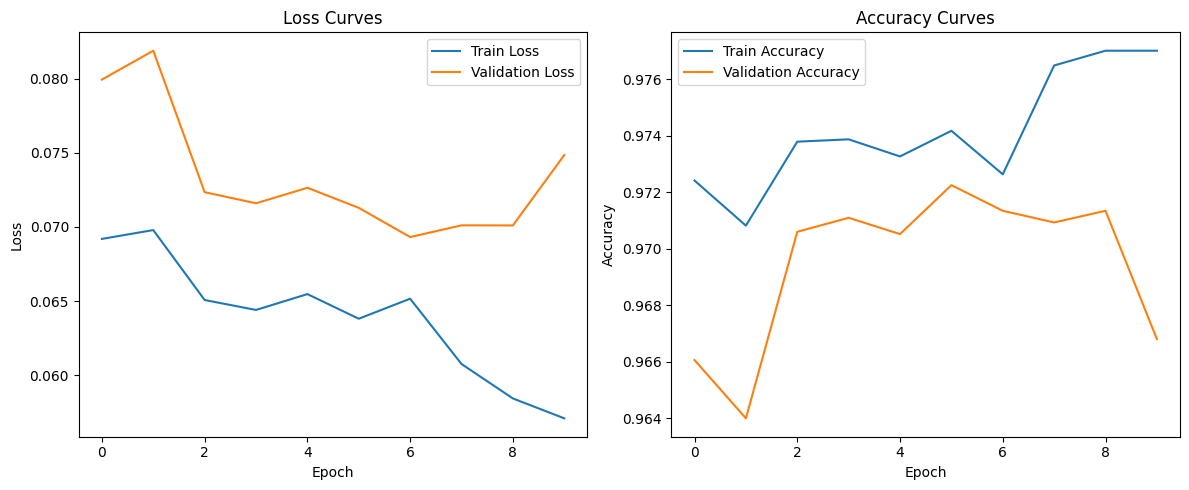

In [41]:
import matplotlib.pyplot as plt

## [ TODO 8 ] Plot loss and accuracy curves

# Plotting loss curves
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history['loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Validation Loss')
plt.title('Loss Curves')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Plotting accuracy curves
plt.subplot(1, 2, 2)
plt.plot(history['acc'], label='Train Accuracy')
plt.plot(history['val_acc'], label='Validation Accuracy')
plt.title('Accuracy Curves')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

In [42]:
from sklearn.metrics import confusion_matrix, classification_report

## [ TODO 9 ] Test evaluation
# - Create test dataset and loader
# - Predict and collect results
# - Print confusion matrix and classification report

# Create test dataset and loader
test_dataset = URLDataset(urls_test, labels_test, MAX_URL_LEN, N, n2i_urls)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE)

# Predict and collect results
model.eval() # Set model to evaluation mode
y_true = []
y_pred = []

with torch.no_grad():
    for x, y in test_loader:
        x = x.to(device)
        outputs = model(x)
        predicted = (outputs > 0.5).squeeze().cpu().numpy() # Convert probabilities to binary predictions
        y_true.extend(y.cpu().numpy())
        y_pred.extend(predicted)

# Print confusion matrix and classification report
print('Confusion Matrix:')
print(confusion_matrix(y_true, y_pred))
print('\nClassification Report:')
print(classification_report(y_true, y_pred))

Confusion Matrix:
[[6947  196]
 [ 201 4766]]

Classification Report:
              precision    recall  f1-score   support

         0.0       0.97      0.97      0.97      7143
         1.0       0.96      0.96      0.96      4967

    accuracy                           0.97     12110
   macro avg       0.97      0.97      0.97     12110
weighted avg       0.97      0.97      0.97     12110



## Questions

**Q1: Analyze model performance. Does lower loss indicate higher accuracy?** (2 pts)

**Your Answer:**

Based on the history data and the generated plots, a clear inverse relationship exists. As the model trains and its loss decreases, its ability to correctly classify URLs generally improves. This holds true for both the training and validation sets, despite some minor fluctuations in the validation metrics.

**Q2: Is large window_size (e.g., 50) good? Other compression methods?** (2 pts)

**Your Answer:**

A large window_size like 50 is generally not good because it significantly increases computational cost, dilutes relevant local context, and introduces noise. Malicious patterns in URLs are often localized, making smaller window sizes more effective.


## Submission
Submit: `homework-3-student-20260205.ipynb` + `model-url-cnn.pt`